In [1]:
# ============================================
# Cell 1: Imports, warnings, plotting setup, and project paths
# Purpose:
# - Load all dependencies required for feature optimization
# - Keep project paths consistent with the corrected project structure
# - Prepare plotting for feature diagnostics and selection review
# ============================================

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import linregress
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"
FIG_DIR = REPORT_DIR / "figures"
META_DIR = REPORT_DIR / "metadata"

for folder in [DATA_DIR, PROCESSED_DIR, REPORT_DIR, FIG_DIR, META_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

TRAIN_START = "2015-01-01"
TRAIN_END = "2024-12-31"
LIVE_START = "2025-01-01"
LIVE_END = "2026-03-01"

print("Project root:", PROJECT_ROOT)
print("Processed directory:", PROCESSED_DIR)

Project root: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha
Processed directory: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed


In [2]:
# ============================================
# Cell 2: Load Phase 1 master dataset
# Purpose:
# - Start from the clean raw + macro data created in Phase 1
# - Rebuild an optimized feature stack from the cleanest possible source
# - Avoid depending on earlier feature choices when designing upgraded inputs
# ============================================

phase_1_parquet = PROCESSED_DIR / "phase_1_master_data.parquet"
phase_1_csv = PROCESSED_DIR / "phase_1_master_data.csv"

print("Looking for Phase 1 files:")
print("Parquet:", phase_1_parquet)
print("CSV:", phase_1_csv)

if phase_1_parquet.exists():
    df = pd.read_parquet(phase_1_parquet)
    print("Loaded Parquet file")
elif phase_1_csv.exists():
    df = pd.read_csv(phase_1_csv, index_col=0, parse_dates=True)
    print("Loaded CSV file")
else:
    raise FileNotFoundError(
        "Phase 1 data file was not found. "
        f"Expected one of:\n{phase_1_parquet}\n{phase_1_csv}"
    )

df.index = pd.to_datetime(df.index)
df = df.sort_index()

print("\nDataset shape:", df.shape)
print("\nDataset preview:")
print(df.head())# ============================================
# Cell 2: Load Phase 1 master dataset
# Purpose:
# - Start from the clean raw + macro data created in Phase 1
# - Rebuild an optimized feature stack from the cleanest possible source
# - Avoid depending on earlier feature choices when designing upgraded inputs
# ============================================

phase_1_parquet = PROCESSED_DIR / "phase_1_master_data.parquet"
phase_1_csv = PROCESSED_DIR / "phase_1_master_data.csv"

print("Looking for Phase 1 files:")
print("Parquet:", phase_1_parquet)
print("CSV:", phase_1_csv)

if phase_1_parquet.exists():
    df = pd.read_parquet(phase_1_parquet)
    print("Loaded Parquet file")
elif phase_1_csv.exists():
    df = pd.read_csv(phase_1_csv, index_col=0, parse_dates=True)
    print("Loaded CSV file")
else:
    raise FileNotFoundError(
        "Phase 1 data file was not found. "
        f"Expected one of:\n{phase_1_parquet}\n{phase_1_csv}"
    )

df.index = pd.to_datetime(df.index)
df = df.sort_index()

print("\nDataset shape:", df.shape)
print("\nDataset preview:")
print(df.head())

Looking for Phase 1 files:
Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_1_master_data.parquet
CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_1_master_data.csv
Loaded Parquet file

Dataset shape: (3057, 11)

Dataset preview:
            spy_adj_close   spy_close    spy_high     spy_low    spy_open  \
Date                                                                        
2014-01-02     148.580261  182.919998  184.070007  182.479996  183.979996   
2014-01-03     148.555939  182.889999  183.600006  182.630005  183.229996   
2014-01-06     148.125412  182.360001  183.559998  182.080002  183.490005   
2014-01-07     149.035126  183.479996  183.789993  182.949997  183.089996   
2014-01-08     149.067657  183.520004  183.830002  182.889999  183.449997   

            spy_volume  vix_close  tnx_close  is_train_period  is_live_period  \
Date                                                                            
2014-01-02

In [3]:
# ============================================
# Cell 3: Validation before optimization
# Purpose:
# - Confirm the required core market and macro columns exist
# - Fail early if the Phase 1 data contract is broken
# - Ensure the optimized feature package starts from a reliable input set
# ============================================

required_cols = [
    "spy_open",
    "spy_high",
    "spy_low",
    "spy_close",
    "spy_adj_close",
    "spy_volume",
    "vix_close",
    "tnx_close",
]

missing_cols = [col for col in required_cols if col not in df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for Phase 2.5: {missing_cols}")

assert df.index.is_monotonic_increasing, "Index must be sorted ascending."
assert df.index.duplicated().sum() == 0, "Duplicate timestamps are not allowed."

for col in required_cols:
    if df[col].isna().any():
        raise ValueError(f"Column '{col}' contains missing values before feature optimization.")

print("Phase 2.5 validation passed successfully.")

Phase 2.5 validation passed successfully.


In [4]:
# ============================================
# Cell 4: Helper functions for leak-free feature engineering
# Purpose:
# - Centralize reusable calculations for stronger inputs
# - Keep formulas transparent, reproducible, and leakage-safe
# - IMPORTANT: Every finished feature will be shifted by one day at creation time
# ============================================

def compute_log_return(series: pd.Series) -> pd.Series:
    return np.log(series / series.shift(1))


def compute_rolling_return(series: pd.Series, window: int) -> pd.Series:
    return series.pct_change(window)


def compute_true_range(high: pd.Series, low: pd.Series, close: pd.Series) -> pd.Series:
    prev_close = close.shift(1)
    tr_components = pd.concat(
        [
            high - low,
            (high - prev_close).abs(),
            (low - prev_close).abs(),
        ],
        axis=1,
    )
    return tr_components.max(axis=1)


def compute_atr(high: pd.Series, low: pd.Series, close: pd.Series, window: int = 14) -> pd.Series:
    true_range = compute_true_range(high, low, close)
    return true_range.rolling(window=window).mean()


def compute_rsi(series: pd.Series, window: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0.0)
    loss = -delta.clip(upper=0.0)

    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))


def compute_rolling_zscore(series: pd.Series, window: int) -> pd.Series:
    rolling_mean = series.rolling(window=window).mean()
    rolling_std = series.rolling(window=window).std()
    return (series - rolling_mean) / rolling_std.replace(0, np.nan)


def compute_rolling_percentile_rank(series: pd.Series, window: int) -> pd.Series:
    def pct_rank_last(values):
        s = pd.Series(values)
        return s.rank(pct=True).iloc[-1]
    return series.rolling(window=window).apply(pct_rank_last, raw=False)


def compute_rolling_slope(series: pd.Series, window: int) -> pd.Series:
    x = np.arange(window)

    def slope_func(y):
        if np.isnan(y).any():
            return np.nan
        slope, _, _, _, _ = linregress(x, y)
        return slope

    return series.rolling(window=window).apply(slope_func, raw=True)


def compute_rolling_r2(series: pd.Series, window: int) -> pd.Series:
    x = np.arange(window)

    def r2_func(y):
        if np.isnan(y).any():
            return np.nan
        _, _, r_value, _, _ = linregress(x, y)
        return r_value ** 2

    return series.rolling(window=window).apply(r2_func, raw=True)


def compute_drawdown(series: pd.Series, window: int = 252) -> pd.Series:
    rolling_peak = series.rolling(window=window, min_periods=1).max()
    return series / rolling_peak - 1.0


def compute_downside_volatility(returns: pd.Series, window: int = 20) -> pd.Series:
    downside = returns.where(returns < 0, 0.0)
    return downside.rolling(window=window).std()


def compute_upside_volatility(returns: pd.Series, window: int = 20) -> pd.Series:
    upside = returns.where(returns > 0, 0.0)
    return upside.rolling(window=window).std()


def compute_trend_persistence(returns: pd.Series, window: int) -> pd.Series:
    return (returns > 0).rolling(window=window).mean()


def compute_return_skew(series: pd.Series, window: int) -> pd.Series:
    return series.rolling(window=window).skew()


def compute_return_kurtosis(series: pd.Series, window: int) -> pd.Series:
    return series.rolling(window=window).kurt()


def compute_gap_open_pct(open_series: pd.Series, close_series: pd.Series) -> pd.Series:
    return open_series / close_series.shift(1) - 1.0


def compute_downside_tail_frequency(returns: pd.Series, window: int, threshold: float) -> pd.Series:
    return (returns < threshold).rolling(window=window).mean()


def compute_upside_tail_frequency(returns: pd.Series, window: int, threshold: float) -> pd.Series:
    return (returns > threshold).rolling(window=window).mean()


def shift_feature(series: pd.Series) -> pd.Series:
    """
    CRITICAL:
    Every finished feature is shifted by 1 so that feature at date t only contains
    information available at the close of date t-1 or earlier.
    """
    return series.shift(1)


def drop_highly_correlated_features(feature_df: pd.DataFrame, threshold: float = 0.95):
    corr_matrix = feature_df.corr().abs()
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    kept_df = feature_df.drop(columns=to_drop, errors="ignore").copy()

    return kept_df, to_drop


def save_dataframe_with_fallback(df_to_save: pd.DataFrame, parquet_path: Path, csv_path: Path) -> None:
    df_to_save.to_csv(csv_path, index=True)
    try:
        df_to_save.to_parquet(parquet_path, index=True)
        print(f"Saved Parquet: {parquet_path}")
    except Exception as exc:
        print(f"Parquet save skipped due to environment issue: {exc}")
    print(f"Saved CSV: {csv_path}")

In [5]:
# ============================================
# Cell 5: Create leak-free optimized feature blocks
# Purpose:
# - Build a stronger and safer feature library
# - IMPORTANT: every engineered feature is shifted at creation time
# - Prevent any current-bar information from leaking into the prediction row
# ============================================

features = pd.DataFrame(index=df.index)

# ----------------------------------
# Core intermediate series
# These are raw helper series only. Final saved features will be shifted.
# ----------------------------------
ret_1d_raw = df["spy_close"].pct_change()
log_ret_1d_raw = compute_log_return(df["spy_close"])
gap_open_pct_raw = compute_gap_open_pct(df["spy_open"], df["spy_close"])
atr_14_raw = compute_atr(df["spy_high"], df["spy_low"], df["spy_close"], window=14)

# ----------------------------------
# Price and return features
# ----------------------------------
features["ret_1d"] = shift_feature(ret_1d_raw)
features["log_ret_1d"] = shift_feature(log_ret_1d_raw)
features["ret_3d"] = shift_feature(compute_rolling_return(df["spy_close"], 3))
features["ret_5d"] = shift_feature(compute_rolling_return(df["spy_close"], 5))
features["ret_10d"] = shift_feature(compute_rolling_return(df["spy_close"], 10))
features["ret_20d"] = shift_feature(compute_rolling_return(df["spy_close"], 20))
features["ret_60d"] = shift_feature(compute_rolling_return(df["spy_close"], 60))

# ----------------------------------
# Trend quality features
# ----------------------------------
for window in [10, 20, 50, 100, 200]:
    sma_raw = df["spy_close"].rolling(window).mean()
    ema_raw = df["spy_close"].ewm(span=window, adjust=False).mean()

    features[f"sma_{window}"] = shift_feature(sma_raw)
    features[f"ema_{window}"] = shift_feature(ema_raw)
    features[f"price_to_sma_{window}"] = shift_feature(df["spy_close"] / sma_raw - 1.0)
    features[f"sma_slope_{window}"] = shift_feature(compute_rolling_slope(df["spy_close"], window))
    features[f"sma_r2_{window}"] = shift_feature(compute_rolling_r2(df["spy_close"], window))

features["sma_10_20_spread"] = shift_feature(
    df["spy_close"].rolling(10).mean() / df["spy_close"].rolling(20).mean() - 1.0
)
features["sma_20_50_spread"] = shift_feature(
    df["spy_close"].rolling(20).mean() / df["spy_close"].rolling(50).mean() - 1.0
)
features["sma_50_200_spread"] = shift_feature(
    df["spy_close"].rolling(50).mean() / df["spy_close"].rolling(200).mean() - 1.0
)

trend_slope_vol_adj_20_raw = compute_rolling_slope(df["spy_close"], 20) / ret_1d_raw.rolling(20).std().replace(0, np.nan)
trend_slope_vol_adj_50_raw = compute_rolling_slope(df["spy_close"], 50) / ret_1d_raw.rolling(50).std().replace(0, np.nan)

features["trend_slope_vol_adj_20"] = shift_feature(trend_slope_vol_adj_20_raw)
features["trend_slope_vol_adj_50"] = shift_feature(trend_slope_vol_adj_50_raw)
features["trend_persistence_20"] = shift_feature(compute_trend_persistence(ret_1d_raw, 20))
features["trend_persistence_60"] = shift_feature(compute_trend_persistence(ret_1d_raw, 60))
features["trend_quality_20"] = shift_feature(
    trend_slope_vol_adj_20_raw * compute_rolling_r2(df["spy_close"], 20)
)
features["trend_quality_50"] = shift_feature(
    trend_slope_vol_adj_50_raw * compute_rolling_r2(df["spy_close"], 50)
)

# ----------------------------------
# Volatility structure features
# ----------------------------------
realized_vol_5_raw = ret_1d_raw.rolling(5).std()
realized_vol_10_raw = ret_1d_raw.rolling(10).std()
realized_vol_20_raw = ret_1d_raw.rolling(20).std()
realized_vol_60_raw = ret_1d_raw.rolling(60).std()
realized_vol_120_raw = ret_1d_raw.rolling(120).std()

features["realized_vol_5"] = shift_feature(realized_vol_5_raw)
features["realized_vol_10"] = shift_feature(realized_vol_10_raw)
features["realized_vol_20"] = shift_feature(realized_vol_20_raw)
features["realized_vol_60"] = shift_feature(realized_vol_60_raw)
features["realized_vol_120"] = shift_feature(realized_vol_120_raw)

features["atr_14"] = shift_feature(atr_14_raw)
features["atr_pct_14"] = shift_feature(atr_14_raw / df["spy_close"])

features["vol_ratio_5_20"] = shift_feature(realized_vol_5_raw / realized_vol_20_raw.replace(0, np.nan))
features["vol_ratio_20_60"] = shift_feature(realized_vol_20_raw / realized_vol_60_raw.replace(0, np.nan))
features["atr_to_realized_vol_20"] = shift_feature((atr_14_raw / df["spy_close"]) / realized_vol_20_raw.replace(0, np.nan))
features["vol_of_vol_20"] = shift_feature(realized_vol_20_raw.rolling(20).std())
features["vol_of_vol_60"] = shift_feature(realized_vol_60_raw.rolling(20).std())

# ----------------------------------
# Momentum and mean-reversion features
# ----------------------------------
rsi_14_raw = compute_rsi(df["spy_close"], 14)
rsi_28_raw = compute_rsi(df["spy_close"], 28)
zscore_20_raw = compute_rolling_zscore(df["spy_close"], 20)
zscore_60_raw = compute_rolling_zscore(df["spy_close"], 60)

features["rsi_14"] = shift_feature(rsi_14_raw)
features["rsi_28"] = shift_feature(rsi_28_raw)
features["zscore_20"] = shift_feature(zscore_20_raw)
features["zscore_60"] = shift_feature(zscore_60_raw)
features["distance_from_20d_mean"] = shift_feature(df["spy_close"] / df["spy_close"].rolling(20).mean() - 1.0)
features["distance_from_50d_mean"] = shift_feature(df["spy_close"] / df["spy_close"].rolling(50).mean() - 1.0)
features["distance_from_200d_mean"] = shift_feature(df["spy_close"] / df["spy_close"].rolling(200).mean() - 1.0)
features["rsi_x_zscore"] = shift_feature(((rsi_14_raw - 50.0) / 50.0) * zscore_20_raw)

# ----------------------------------
# Volume and participation features
# ----------------------------------
volume_sma_20_raw = df["spy_volume"].rolling(20).mean()
volume_sma_60_raw = df["spy_volume"].rolling(60).mean()

features["volume_sma_20"] = shift_feature(volume_sma_20_raw)
features["volume_sma_60"] = shift_feature(volume_sma_60_raw)
features["volume_ratio_20"] = shift_feature(df["spy_volume"] / volume_sma_20_raw)
features["volume_ratio_60"] = shift_feature(df["spy_volume"] / volume_sma_60_raw)
features["volume_zscore_20"] = shift_feature(compute_rolling_zscore(df["spy_volume"], 20))
features["volume_trend_20"] = shift_feature(compute_rolling_slope(np.log(df["spy_volume"].replace(0, np.nan)), 20))

# ----------------------------------
# Risk and distribution shape features
# ----------------------------------
drawdown_252_raw = compute_drawdown(df["spy_close"], 252)
downside_vol_20_raw = compute_downside_volatility(ret_1d_raw, 20)
downside_vol_60_raw = compute_downside_volatility(ret_1d_raw, 60)
upside_vol_20_raw = compute_upside_volatility(ret_1d_raw, 20)
upside_vol_60_raw = compute_upside_volatility(ret_1d_raw, 60)

features["drawdown_252"] = shift_feature(drawdown_252_raw)
features["downside_vol_20"] = shift_feature(downside_vol_20_raw)
features["downside_vol_60"] = shift_feature(downside_vol_60_raw)
features["upside_vol_20"] = shift_feature(upside_vol_20_raw)
features["upside_vol_60"] = shift_feature(upside_vol_60_raw)
features["downside_upside_vol_ratio_20"] = shift_feature(downside_vol_20_raw / upside_vol_20_raw.replace(0, np.nan))
features["return_skew_20"] = shift_feature(compute_return_skew(ret_1d_raw, 20))
features["return_skew_60"] = shift_feature(compute_return_skew(ret_1d_raw, 60))
features["return_kurtosis_20"] = shift_feature(compute_return_kurtosis(ret_1d_raw, 20))
features["return_kurtosis_60"] = shift_feature(compute_return_kurtosis(ret_1d_raw, 60))
features["intraday_range_pct"] = shift_feature((df["spy_high"] - df["spy_low"]) / df["spy_close"])
features["gap_open_pct"] = shift_feature(gap_open_pct_raw)
features["downside_tail_freq_20"] = shift_feature(compute_downside_tail_frequency(ret_1d_raw, 20, -0.01))
features["upside_tail_freq_20"] = shift_feature(compute_upside_tail_frequency(ret_1d_raw, 20, 0.01))
features["downside_tail_freq_60"] = shift_feature(compute_downside_tail_frequency(ret_1d_raw, 60, -0.01))
features["upside_tail_freq_60"] = shift_feature(compute_upside_tail_frequency(ret_1d_raw, 60, 0.01))

# ----------------------------------
# Macro level, change, percentile, and context features
# ----------------------------------
vix_ret_1d_raw = df["vix_close"].pct_change(1)
tnx_change_1d_raw = df["tnx_close"].diff(1)

features["vix_level"] = shift_feature(df["vix_close"])
features["vix_ret_1d"] = shift_feature(vix_ret_1d_raw)
features["vix_change_5d"] = shift_feature(df["vix_close"].pct_change(5))
features["vix_zscore_20"] = shift_feature(compute_rolling_zscore(df["vix_close"], 20))
features["vix_percentile_252"] = shift_feature(compute_rolling_percentile_rank(df["vix_close"], 252))

features["tnx_level"] = shift_feature(df["tnx_close"])
features["tnx_change_1d"] = shift_feature(tnx_change_1d_raw)
features["tnx_change_5d"] = shift_feature(df["tnx_close"].diff(5))
features["tnx_zscore_20"] = shift_feature(compute_rolling_zscore(df["tnx_close"], 20))
features["tnx_percentile_252"] = shift_feature(compute_rolling_percentile_rank(df["tnx_close"], 252))

# ----------------------------------
# Cross-asset and interaction features
# ----------------------------------
features["spy_vix_corr_20"] = shift_feature(ret_1d_raw.rolling(20).corr(vix_ret_1d_raw))
features["spy_vix_corr_60"] = shift_feature(ret_1d_raw.rolling(60).corr(vix_ret_1d_raw))
features["spy_tnx_corr_20"] = shift_feature(ret_1d_raw.rolling(20).corr(tnx_change_1d_raw))
features["spy_tnx_corr_60"] = shift_feature(ret_1d_raw.rolling(60).corr(tnx_change_1d_raw))
features["trend_x_vix"] = shift_feature((trend_slope_vol_adj_20_raw * compute_rolling_r2(df["spy_close"], 20)) * compute_rolling_zscore(df["vix_close"], 20))
features["trend_x_vol"] = shift_feature((trend_slope_vol_adj_20_raw * compute_rolling_r2(df["spy_close"], 20)) * realized_vol_20_raw)
features["drawdown_percentile_252"] = shift_feature(compute_rolling_percentile_rank(drawdown_252_raw, 252))
features["atr_percentile_252"] = shift_feature(compute_rolling_percentile_rank(atr_14_raw / df["spy_close"], 252))
features["realized_vol_percentile_252"] = shift_feature(compute_rolling_percentile_rank(realized_vol_20_raw, 252))
features["price_to_200d_x_vix"] = shift_feature((df["spy_close"] / df["spy_close"].rolling(200).mean() - 1.0) * compute_rolling_zscore(df["vix_close"], 20))

print("Leak-free optimized raw feature matrix created.")
print("Raw optimized feature matrix shape:", features.shape)
print(features.head())

Leak-free optimized raw feature matrix created.
Raw optimized feature matrix shape: (3057, 103)
              ret_1d  log_ret_1d    ret_3d  ret_5d  ret_10d  ret_20d  ret_60d  \
Date                                                                            
2014-01-02       NaN         NaN       NaN     NaN      NaN      NaN      NaN   
2014-01-03       NaN         NaN       NaN     NaN      NaN      NaN      NaN   
2014-01-06 -0.000164   -0.000164       NaN     NaN      NaN      NaN      NaN   
2014-01-07 -0.002898   -0.002902       NaN     NaN      NaN      NaN      NaN   
2014-01-08  0.006142    0.006123  0.003061     NaN      NaN      NaN      NaN   

            sma_10      ema_10  price_to_sma_10  ...  spy_vix_corr_20  \
Date                                             ...                    
2014-01-02     NaN         NaN              NaN  ...              NaN   
2014-01-03     NaN  182.919998              NaN  ...              NaN   
2014-01-06     NaN  182.914544              

In [6]:
# ============================================
# Cell 6: Create provisional screening targets
# Purpose:
# - Build temporary screening targets for feature scoring
# - These are forward-looking by design and are NOT used as features
# - This cell remains separate from the final formal target notebook
# ============================================

screen_df = pd.DataFrame(index=df.index)

screen_df["screen_forward_return_1d"] = df["spy_close"].pct_change().shift(-1)
screen_df["screen_forward_return_5d"] = df["spy_close"].pct_change(5).shift(-5)
screen_df["screen_forward_return_10d"] = df["spy_close"].pct_change(10).shift(-10)

screen_df["screen_high_conviction_up_5d"] = (screen_df["screen_forward_return_5d"] > 0.005).astype(int)
screen_df["screen_high_conviction_up_10d"] = (screen_df["screen_forward_return_10d"] > 0.010).astype(int)

screen_df["screen_above_200d_now"] = (df["spy_close"] > df["spy_close"].rolling(200).mean()).astype(int)
screen_df["screen_trend_conditional_up_5d"] = (
    (screen_df["screen_forward_return_5d"] > 0.005) &
    (screen_df["screen_above_200d_now"] == 1)
).astype(int)

print("Provisional screening targets created.")
print(screen_df.head())

Provisional screening targets created.
            screen_forward_return_1d  screen_forward_return_5d  \
Date                                                             
2014-01-02                 -0.000164                  0.003936   
2014-01-03                 -0.002898                  0.006835   
2014-01-06                  0.006142                 -0.003674   
2014-01-07                  0.000218                  0.001036   
2014-01-08                  0.000654                  0.006212   

            screen_forward_return_10d  screen_high_conviction_up_5d  \
Date                                                                  
2014-01-02                   0.008200                             0   
2014-01-03                   0.004101                             1   
2014-01-06                   0.009980                             0   
2014-01-07                   0.004469                             0   
2014-01-08                  -0.003978                             1   



In [7]:
# ============================================
# Cell 7: Assemble the leak-free screening dataset
# Purpose:
# - Join the lagged optimized features with screening targets
# - Remove leakage rows created by rolling windows and forward targets
# - Preserve only valid rows inside the research horizon
# ============================================

optimized_df = df.copy()
optimized_df = optimized_df.join(features, how="left")
optimized_df = optimized_df.join(screen_df, how="left")

engineered_feature_cols = features.columns.tolist()

required_screen_cols = [
    "screen_forward_return_5d",
    "screen_high_conviction_up_5d",
    "screen_high_conviction_up_10d",
    "screen_trend_conditional_up_5d",
]

optimized_df = optimized_df.dropna(subset=engineered_feature_cols + required_screen_cols).copy()

optimized_df = optimized_df[
    (optimized_df.index >= pd.Timestamp(TRAIN_START)) &
    (optimized_df.index <= pd.Timestamp(LIVE_END))
].copy()

optimized_df["is_train_period"] = (
    (optimized_df.index >= pd.Timestamp(TRAIN_START)) &
    (optimized_df.index <= pd.Timestamp(TRAIN_END))
)

optimized_df["is_live_period"] = (
    (optimized_df.index >= pd.Timestamp(LIVE_START)) &
    (optimized_df.index <= pd.Timestamp(LIVE_END))
)

optimized_df["dataset_partition"] = np.select(
    [
        optimized_df["is_train_period"],
        optimized_df["is_live_period"],
    ],
    [
        "train",
        "live",
    ],
    default="unused"
)

print("Leak-free optimized dataset created.")
print("Optimized dataset shape:", optimized_df.shape)
print("\nPartition counts:")
print(optimized_df["dataset_partition"].value_counts(dropna=False))

Leak-free optimized dataset created.
Optimized dataset shape: (2780, 121)

Partition counts:
dataset_partition
train    2496
live      284
Name: count, dtype: int64


In [8]:
# ============================================
# Cell 8: Remove highly correlated features before screening
# Purpose:
# - Reduce redundancy in the feature library
# - Keep only one representative from near-duplicate feature clusters
# - Improve model stability before the later modeling pass
# ============================================

train_feature_df = optimized_df.loc[optimized_df["is_train_period"], engineered_feature_cols].copy()
train_feature_df = train_feature_df.replace([np.inf, -np.inf], np.nan)

missing_ratio = train_feature_df.isna().mean()
high_missing_cols = missing_ratio[missing_ratio > 0.10].index.tolist()

reduced_feature_df = train_feature_df.drop(columns=high_missing_cols, errors="ignore").copy()
reduced_feature_df = reduced_feature_df.apply(lambda col: col.fillna(col.median()), axis=0)

decollinearized_feature_df, dropped_corr_cols = drop_highly_correlated_features(
    reduced_feature_df,
    threshold=0.95,
)

selected_candidate_cols = decollinearized_feature_df.columns.tolist()

print("Initial engineered features:", len(engineered_feature_cols))
print("Dropped due to >10% missing ratio:", len(high_missing_cols))
print("Dropped due to correlation filter:", len(dropped_corr_cols))
print("Remaining candidate features:", len(selected_candidate_cols))

Initial engineered features: 103
Dropped due to >10% missing ratio: 0
Dropped due to correlation filter: 21
Remaining candidate features: 82


In [9]:
# ============================================
# Cell 9: Score candidate features on training data
# Purpose:
# - Measure statistical usefulness of each candidate feature
# - Use multiple screening views rather than a single metric
# - Prefer features that are helpful across both regression and classification views
# ============================================

screen_train = optimized_df.loc[optimized_df["is_train_period"]].copy()

X_train = screen_train[selected_candidate_cols].copy()
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_train = X_train.apply(lambda col: col.fillna(col.median()), axis=0)

y_reg_5d = screen_train["screen_forward_return_5d"].copy()
y_clf_5d = screen_train["screen_high_conviction_up_5d"].copy()
y_clf_trend = screen_train["screen_trend_conditional_up_5d"].copy()

feature_stats = []

mi_reg = mutual_info_regression(X_train, y_reg_5d, random_state=42)
mi_clf = mutual_info_classif(X_train, y_clf_5d, random_state=42)
mi_trend = mutual_info_classif(X_train, y_clf_trend, random_state=42)

for i, col in enumerate(X_train.columns):
    temp = pd.DataFrame({
        "feature": X_train[col],
        "y_reg_5d": y_reg_5d,
        "y_clf_5d": y_clf_5d,
        "y_clf_trend": y_clf_trend,
    }).dropna()

    corr_reg = temp["feature"].corr(temp["y_reg_5d"])
    corr_abs_reg = abs(corr_reg) if pd.notna(corr_reg) else 0.0

    corr_clf = temp["feature"].corr(temp["y_clf_5d"])
    corr_abs_clf = abs(corr_clf) if pd.notna(corr_clf) else 0.0

    corr_trend = temp["feature"].corr(temp["y_clf_trend"])
    corr_abs_trend = abs(corr_trend) if pd.notna(corr_trend) else 0.0

    feature_stats.append({
        "feature": col,
        "corr_reg_5d": corr_reg,
        "abs_corr_reg_5d": corr_abs_reg,
        "corr_clf_5d": corr_clf,
        "abs_corr_clf_5d": corr_abs_clf,
        "corr_clf_trend": corr_trend,
        "abs_corr_clf_trend": corr_abs_trend,
        "mi_reg_5d": mi_reg[i],
        "mi_clf_5d": mi_clf[i],
        "mi_clf_trend": mi_trend[i],
    })

feature_score_df = pd.DataFrame(feature_stats)

feature_score_df["screen_score"] = (
    feature_score_df["abs_corr_reg_5d"].fillna(0.0) * 0.30 +
    feature_score_df["mi_reg_5d"].fillna(0.0) * 0.20 +
    feature_score_df["abs_corr_clf_5d"].fillna(0.0) * 0.20 +
    feature_score_df["mi_clf_5d"].fillna(0.0) * 0.15 +
    feature_score_df["abs_corr_clf_trend"].fillna(0.0) * 0.10 +
    feature_score_df["mi_clf_trend"].fillna(0.0) * 0.05
)

feature_score_df = feature_score_df.sort_values("screen_score", ascending=False).reset_index(drop=True)

print("Feature screening complete.")
print(feature_score_df.head(30))

Feature screening complete.
                    feature  corr_reg_5d  abs_corr_reg_5d  corr_clf_5d  \
0           realized_vol_60     0.102872         0.102872     0.075284   
1          realized_vol_120     0.093651         0.093651     0.088472   
2          price_to_sma_100    -0.108453         0.108453    -0.074837   
3                atr_pct_14     0.097008         0.097008     0.083774   
4          price_to_sma_200    -0.079984         0.079984    -0.060771   
5              drawdown_252    -0.095832         0.095832    -0.085758   
6          sma_20_50_spread    -0.110639         0.110639    -0.064508   
7     downside_tail_freq_60     0.094417         0.094417     0.084721   
8           realized_vol_20     0.090323         0.090323     0.071533   
9                 vix_level     0.089056         0.089056     0.099541   
10             sma_slope_50    -0.101809         0.101809    -0.055371   
11                  ret_60d    -0.106198         0.106198    -0.063410   
12        

In [10]:
# ============================================
# Cell 10: Regime-aware feature usefulness diagnostics
# Purpose:
# - Check whether some features are especially useful in distinct regimes
# - Prevent globally weak but regime-strong features from being discarded blindly
# - Build a more realistic research view for a regime-aware model
# ============================================

regime_proxy = pd.Series("unknown", index=optimized_df.index, dtype="object")

regime_proxy[
    (optimized_df["distance_from_200d_mean"] > 0) &
    (optimized_df["realized_vol_20"] < optimized_df["realized_vol_60"])
] = "trending"

regime_proxy[
    (optimized_df["zscore_20"].abs() > 1.0) &
    (optimized_df["realized_vol_20"] < optimized_df["realized_vol_60"])
] = "mean_reverting"

regime_proxy[
    (optimized_df["vix_level"] > optimized_df["vix_level"].rolling(252).median()) &
    (optimized_df["realized_vol_20"] > optimized_df["realized_vol_60"])
] = "high_volatility"

regime_proxy[(regime_proxy == "unknown")] = "transition"

optimized_df["phase_2_5_regime_proxy"] = regime_proxy

top_candidate_features = feature_score_df["feature"].head(25).tolist()

regime_feature_rows = []

for regime_name in ["trending", "mean_reverting", "high_volatility", "transition"]:
    regime_subset = optimized_df.loc[
        optimized_df["is_train_period"] &
        (optimized_df["phase_2_5_regime_proxy"] == regime_name)
    ].copy()

    for feature_name in top_candidate_features:
        temp = regime_subset[[feature_name, "screen_forward_return_5d"]].dropna()
        if len(temp) < 100:
            continue

        corr_val = temp[feature_name].corr(temp["screen_forward_return_5d"])
        regime_feature_rows.append({
            "regime": regime_name,
            "feature": feature_name,
            "corr_reg_5d": corr_val,
            "abs_corr_reg_5d": abs(corr_val) if pd.notna(corr_val) else 0.0,
            "rows": len(temp),
        })

regime_feature_df = pd.DataFrame(regime_feature_rows)

print("Regime-aware feature diagnostics complete.")
print(regime_feature_df.sort_values(["regime", "abs_corr_reg_5d"], ascending=[True, False]).head(40))

Regime-aware feature diagnostics complete.
             regime                  feature  corr_reg_5d  abs_corr_reg_5d  \
56  high_volatility         sma_20_50_spread    -0.167263         0.167263   
65  high_volatility          price_to_sma_50    -0.144401         0.144401   
60  high_volatility             sma_slope_50    -0.134415         0.134415   
73  high_volatility            vol_of_vol_20     0.132226         0.132226   
52  high_volatility         price_to_sma_100    -0.131883         0.131883   
61  high_volatility                  ret_60d    -0.130245         0.130245   
58  high_volatility          realized_vol_20     0.129460         0.129460   
70  high_volatility    downside_tail_freq_20     0.125588         0.125588   
67  high_volatility            volume_sma_20     0.123103         0.123103   
53  high_volatility               atr_pct_14     0.121007         0.121007   
51  high_volatility         realized_vol_120     0.118498         0.118498   
50  high_volatility  

In [11]:
# ============================================
# Cell 11: Select the optimized leak-free feature package
# Purpose:
# - Keep a focused, stronger feature set for the next modeling cycle
# - Retain enough breadth for nonlinear models without keeping unnecessary noise
# - Save both the full feature library and the filtered optimized package
# ============================================

TOP_N_FEATURES = 35

top_feature_list = feature_score_df["feature"].head(TOP_N_FEATURES).tolist()

optimized_selected_df = optimized_df.copy()

base_keep_cols = [
    "spy_open",
    "spy_high",
    "spy_low",
    "spy_close",
    "spy_adj_close",
    "spy_volume",
    "vix_close",
    "tnx_close",
    "is_train_period",
    "is_live_period",
    "dataset_partition",
    "screen_forward_return_1d",
    "screen_forward_return_5d",
    "screen_forward_return_10d",
    "screen_high_conviction_up_5d",
    "screen_high_conviction_up_10d",
    "screen_trend_conditional_up_5d",
    "phase_2_5_regime_proxy",
]

optimized_selected_cols = base_keep_cols + top_feature_list
optimized_selected_cols = [col for col in optimized_selected_cols if col in optimized_selected_df.columns]

optimized_selected_df = optimized_selected_df[optimized_selected_cols].copy()

print("Selected optimized leak-free feature package created.")
print("Selected optimized dataset shape:", optimized_selected_df.shape)
print("\nTop selected features:")
print(top_feature_list)

Selected optimized leak-free feature package created.
Selected optimized dataset shape: (2780, 53)

Top selected features:
['realized_vol_60', 'realized_vol_120', 'price_to_sma_100', 'atr_pct_14', 'price_to_sma_200', 'drawdown_252', 'sma_20_50_spread', 'downside_tail_freq_60', 'realized_vol_20', 'vix_level', 'sma_slope_50', 'ret_60d', 'sma_slope_100', 'realized_vol_10', 'atr_14', 'price_to_sma_50', 'volume_sma_60', 'volume_sma_20', 'sma_50_200_spread', 'trend_slope_vol_adj_50', 'downside_tail_freq_20', 'zscore_60', 'rsi_28', 'vol_of_vol_20', 'drawdown_percentile_252', 'realized_vol_5', 'spy_tnx_corr_20', 'atr_percentile_252', 'intraday_range_pct', 'upside_tail_freq_60', 'rsi_14', 'vix_percentile_252', 'ret_20d', 'realized_vol_percentile_252', 'sma_10']


In [12]:
# ============================================
# Cell 12: Validation of the selected leak-free package
# Purpose:
# - Confirm the optimized package is clean enough for the next full modeling pass
# - Check for missing values and infinite values in the selected features
# - Make the next modeling cycle easier to debug
# ============================================

selected_feature_cols = top_feature_list.copy()

missing_selected = optimized_selected_df[selected_feature_cols].isna().sum().sum()
if missing_selected != 0:
    raise ValueError(f"Selected optimized features still contain missing values: {missing_selected}")

infinite_selected = np.isinf(optimized_selected_df[selected_feature_cols].to_numpy()).sum()
if infinite_selected != 0:
    raise ValueError(f"Selected optimized features contain infinite values: {infinite_selected}")

print("Optimized leak-free feature package validation passed.")
print("Number of selected optimized features:", len(selected_feature_cols))

Optimized leak-free feature package validation passed.
Number of selected optimized features: 35


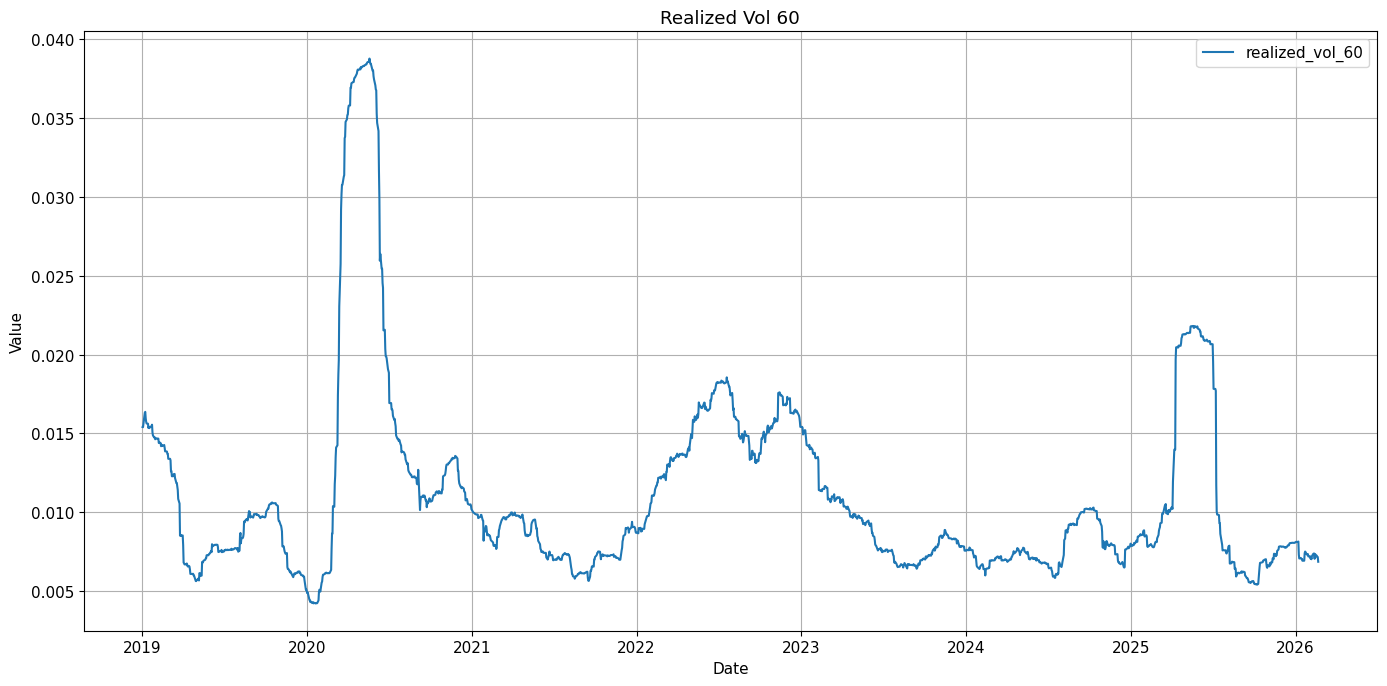

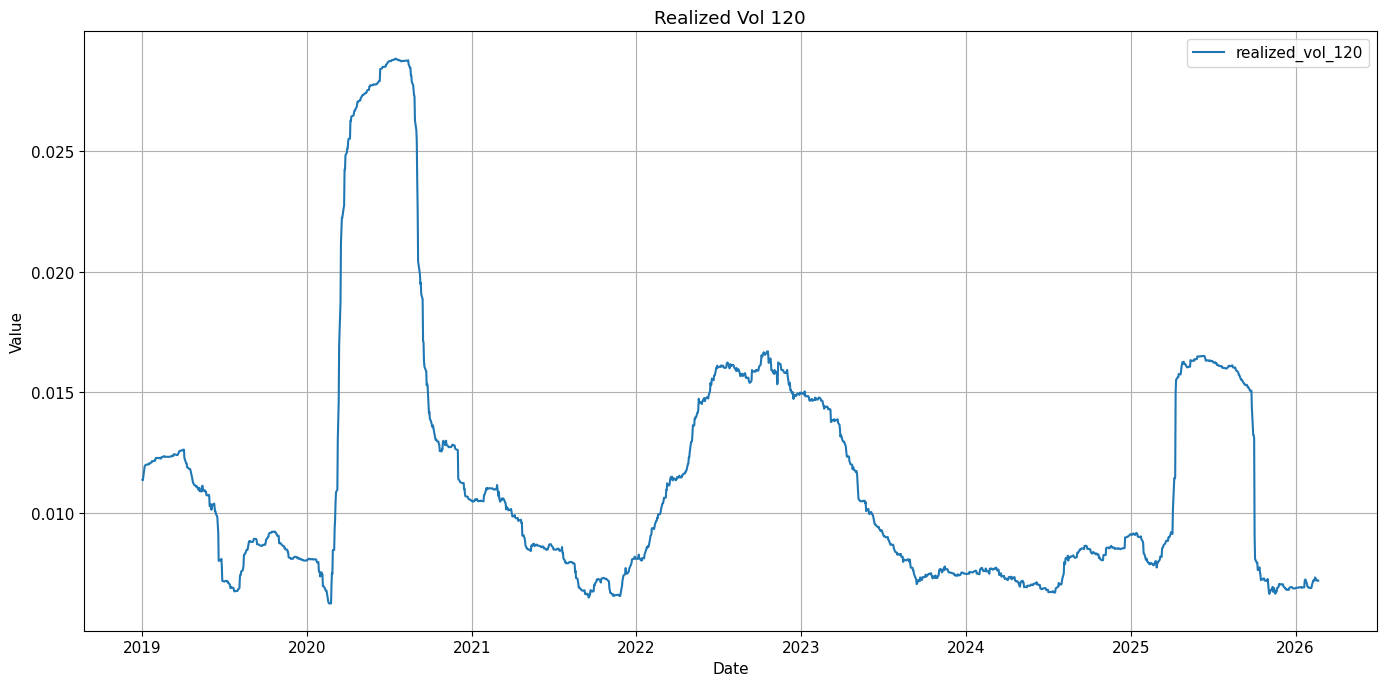

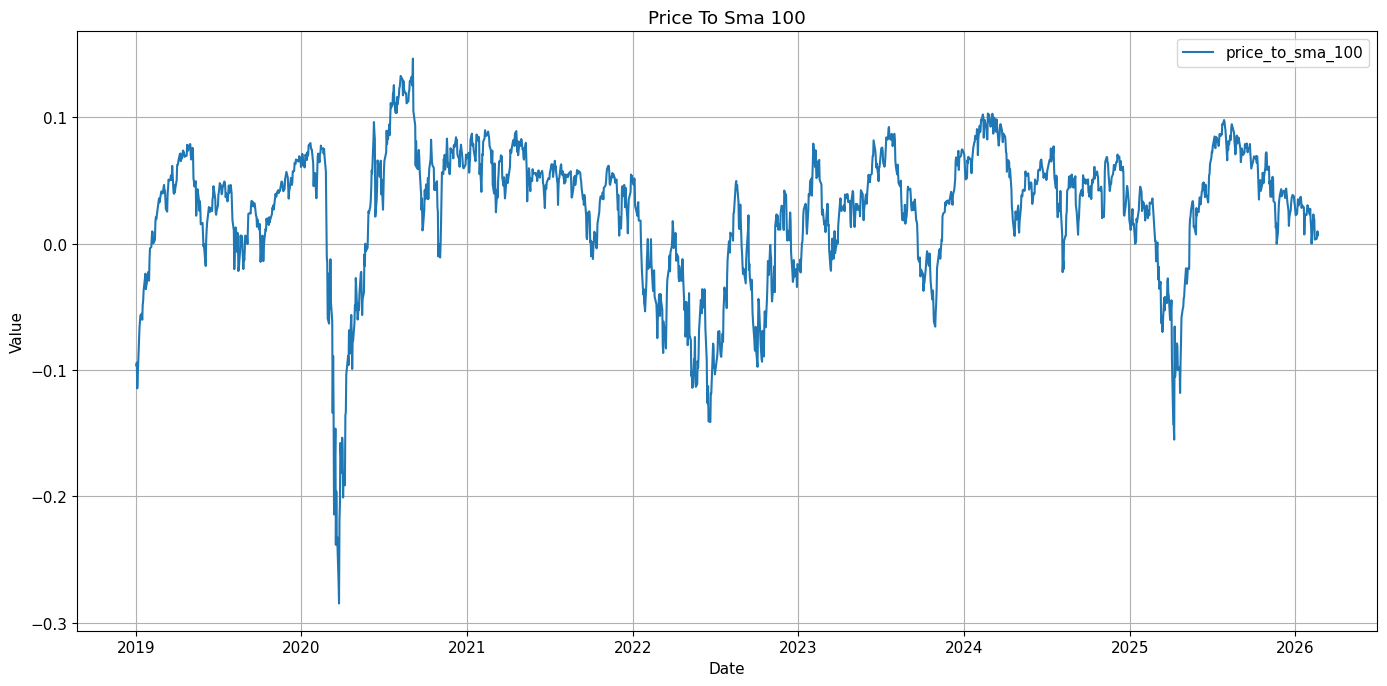

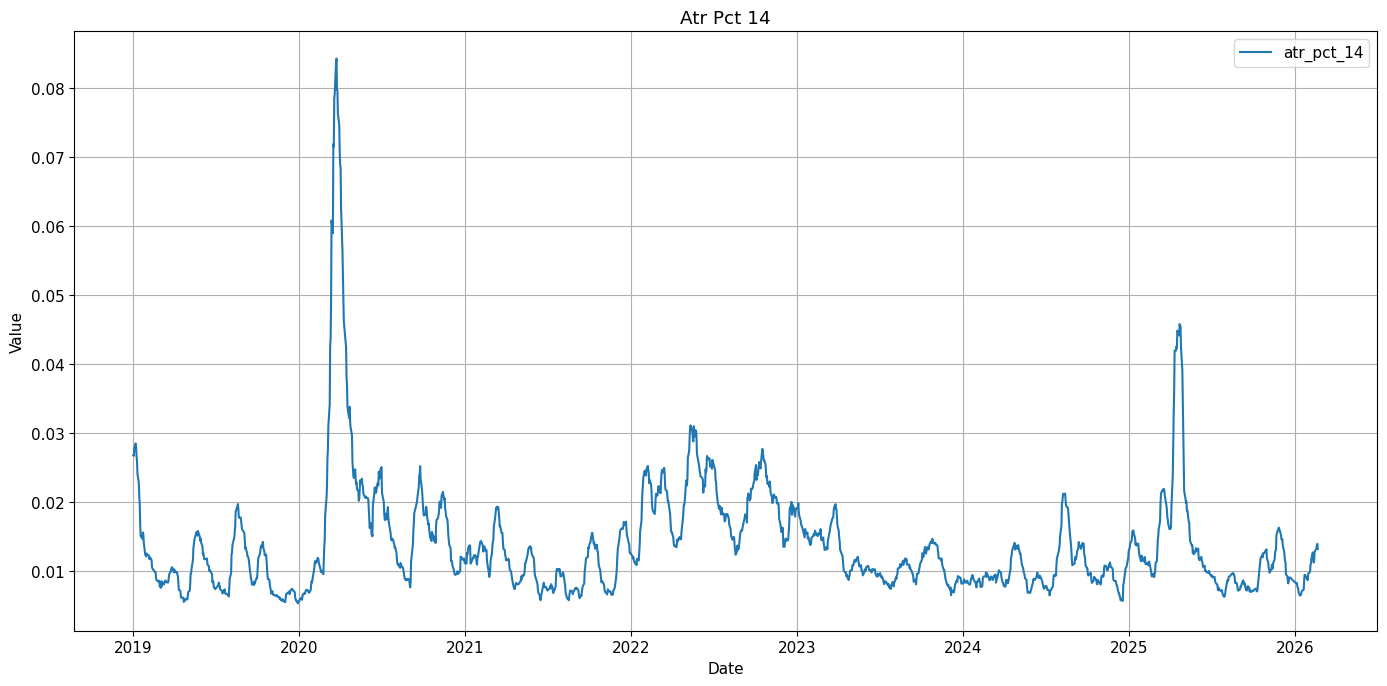

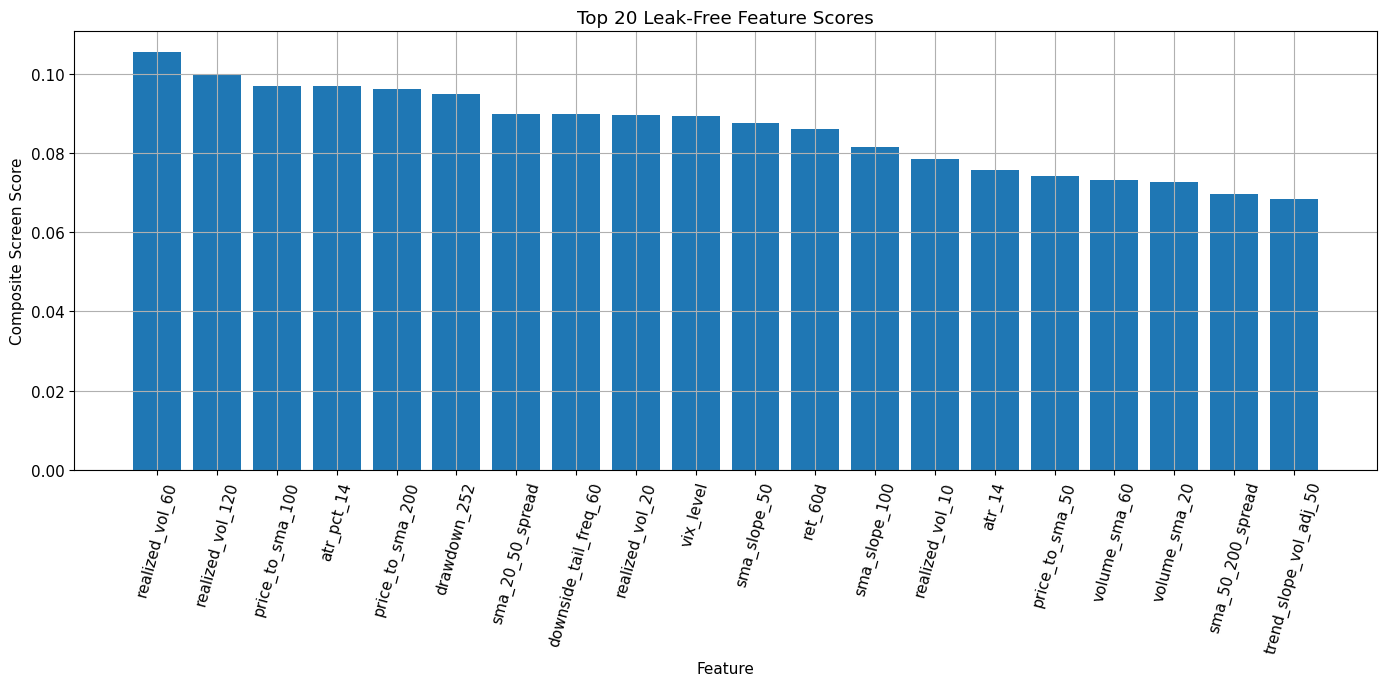

In [13]:
# ============================================
# Cell 13: Visual diagnostics for top optimized features
# Purpose:
# - Inspect whether the strongest features behave sensibly over time
# - Save formal plots for later research review
# - Make the optimization package easier to audit before retraining the pipeline
# ============================================

plot_start_date = "2019-01-01"
plot_df = optimized_selected_df.loc[plot_start_date:].copy()

top_plot_features = top_feature_list[:4]

for feature_name in top_plot_features:
    fig, ax = plt.subplots()
    ax.plot(plot_df.index, plot_df[feature_name], label=feature_name)
    ax.set_title(feature_name.replace("_", " ").title())
    ax.set_xlabel("Date")
    ax.set_ylabel("Value")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"phase_2_5_{feature_name}.png", dpi=150)
    plt.show()

fig, ax = plt.subplots()
ax.bar(feature_score_df["feature"].head(20), feature_score_df["screen_score"].head(20))
ax.set_title("Top 20 Leak-Free Feature Scores")
ax.set_xlabel("Feature")
ax.set_ylabel("Composite Screen Score")
ax.tick_params(axis="x", rotation=75)
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_2_5_top_feature_scores.png", dpi=150)
plt.show()

In [14]:
# ============================================
# Cell 14: Save the full and selected optimization outputs
# Purpose:
# - Persist both the full optimized library and the filtered high-value package
# - Save feature screening reports and metadata
# - Create a stable input contract for the next improved modeling cycle
# ============================================

phase_2_5_full_csv = PROCESSED_DIR / "phase_2_5_full_feature_library.csv"
phase_2_5_full_parquet = PROCESSED_DIR / "phase_2_5_full_feature_library.parquet"

phase_2_5_selected_csv = PROCESSED_DIR / "phase_2_5_selected_feature_data.csv"
phase_2_5_selected_parquet = PROCESSED_DIR / "phase_2_5_selected_feature_data.parquet"

phase_2_5_score_csv = PROCESSED_DIR / "phase_2_5_feature_scores.csv"
phase_2_5_regime_score_csv = PROCESSED_DIR / "phase_2_5_regime_feature_scores.csv"

save_dataframe_with_fallback(optimized_df, phase_2_5_full_parquet, phase_2_5_full_csv)
save_dataframe_with_fallback(optimized_selected_df, phase_2_5_selected_parquet, phase_2_5_selected_csv)

feature_score_df.to_csv(phase_2_5_score_csv, index=False)
print(f"Saved feature score CSV: {phase_2_5_score_csv}")

regime_feature_df.to_csv(phase_2_5_regime_score_csv, index=False)
print(f"Saved regime feature score CSV: {phase_2_5_regime_score_csv}")

phase_2_5_metadata = {
    "phase": "Phase 2.5 - Feature Optimization Package (Leak-Free)",
    "source_notebook": "2.5 - Feature Optimization Package (Leak-Free).ipynb",
    "full_feature_count": int(len(engineered_feature_cols)),
    "candidate_feature_count_after_screening": int(len(selected_candidate_cols)),
    "selected_feature_count": int(len(top_feature_list)),
    "top_features": top_feature_list,
    "dropped_high_missing_cols": high_missing_cols,
    "dropped_corr_cols": dropped_corr_cols,
    "start_date": str(optimized_selected_df.index.min().date()),
    "end_date": str(optimized_selected_df.index.max().date()),
    "row_count_selected": int(len(optimized_selected_df)),
    "column_count_selected": int(optimized_selected_df.shape[1]),
}

phase_2_5_metadata_path = META_DIR / "phase_2_5_metadata.json"
with open(phase_2_5_metadata_path, "w", encoding="utf-8") as f:
    json.dump(phase_2_5_metadata, f, indent=4)

print(f"Saved metadata: {phase_2_5_metadata_path}")
print("Phase 2.5 leak-free optimization package is ready.")

Saved Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_2_5_full_feature_library.parquet
Saved CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_2_5_full_feature_library.csv
Saved Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_2_5_selected_feature_data.parquet
Saved CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_2_5_selected_feature_data.csv
Saved feature score CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_2_5_feature_scores.csv
Saved regime feature score CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_2_5_regime_feature_scores.csv
Saved metadata: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\reports\metadata\phase_2_5_metadata.json
Phase 2.5 leak-free optimization package is ready.


In [17]:
# Cell 15: Loader snippet for the next modeling cycle
# Purpose:
# - Provide a stable loading pattern for the next target/model pass
# - Keep notebook integration deterministic and easy to debug
# - Use the selected optimized feature package as the preferred input
# ============================================

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

phase_2_5_selected_parquet = PROCESSED_DIR / "phase_2_5_selected_feature_data.parquet"
phase_2_5_selected_csv = PROCESSED_DIR / "phase_2_5_selected_feature_data.csv"

print("Looking for Phase 2.5 selected feature files:")
print("Parquet:", phase_2_5_selected_parquet)
print("CSV:", phase_2_5_selected_csv)

if phase_2_5_selected_parquet.exists():
    phase_2_5_data = pd.read_parquet(phase_2_5_selected_parquet)
    print("Loaded Parquet file")
elif phase_2_5_selected_csv.exists():
    phase_2_5_data = pd.read_csv(phase_2_5_selected_csv, index_col=0, parse_dates=True)
    print("Loaded CSV file")
else:
    raise FileNotFoundError(
        "Phase 2.5 selected feature data was not found. "
        f"Expected one of:\n{phase_2_5_selected_parquet}\n{phase_2_5_selected_csv}"
    )

phase_2_5_data.index = pd.to_datetime(phase_2_5_data.index)
phase_2_5_data = phase_2_5_data.sort_index()

print("\nLoaded Phase 2.5 selected dataset preview:")
phase_2_5_selected_parquet = PROCESSED_DIR / "phase_2_5_selected_feature_data.parquet"
phase_2_5_selected_csv = PROCESSED_DIR / "phase_2_5_selected_feature_data.csv"

print("Looking for Phase 2.5 selected feature files:")
print("Parquet:", phase_2_5_selected_parquet)
print("CSV:", phase_2_5_selected_csv)

if phase_2_5_selected_parquet.exists():
    phase_2_5_data = pd.read_parquet(phase_2_5_selected_parquet)
    print("Loaded Parquet file")
elif phase_2_5_selected_csv.exists():
    phase_2_5_data = pd.read_csv(phase_2_5_selected_csv, index_col=0, parse_dates=True)
    print("Loaded CSV file")
else:
    raise FileNotFoundError(
        "Phase 2.5 selected feature data was not found. "
        f"Expected one of:\n{phase_2_5_selected_parquet}\n{phase_2_5_selected_csv}"
    )

phase_2_5_data.index = pd.to_datetime(phase_2_5_data.index)
phase_2_5_data = phase_2_5_data.sort_index()

print("\nLoaded Phase 2.5 selected dataset preview:")
print(phase_2_5_data.head())

Looking for Phase 2.5 selected feature files:
Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_2_5_selected_feature_data.parquet
CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_2_5_selected_feature_data.csv
Loaded Parquet file

Loaded Phase 2.5 selected dataset preview:
Looking for Phase 2.5 selected feature files:
Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_2_5_selected_feature_data.parquet
CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_2_5_selected_feature_data.csv
Loaded Parquet file

Loaded Phase 2.5 selected dataset preview:
              spy_open    spy_high     spy_low   spy_close  spy_adj_close  \
Date                                                                        
2015-02-02  200.050003  202.029999  197.860001  201.919998     167.218262   
2015-02-03  203.000000  204.850006  202.550003  204.839996     169.636398   
2015-02-04  203.919998  205.3800